In [ ]:
from pathlib import Path
import json

import shap
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import display

c:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "models").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError(
            "Could not locate project root"
        )

    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS = PROJECT_ROOT / "models"
REPORTS = PROJECT_ROOT / "reports" / "generated"
DATA = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT)
print("Models:", MODELS)
print("Data:", DATA)
print("Reports:", REPORTS)

Project root: C:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM
Models: C:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\models
Data: C:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\data\processed
Reports: C:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated


In [ ]:
model_path = MODELS / "obesity_risk_pipeline.joblib"
metadata_path = MODELS / "model_metadata.json"

final_model = joblib.load(model_path)

with open(metadata_path, "r") as file:
    metadata = json.load(file)

print("Model loaded successfully")
print("Metadata loaded successfully")

print("\nSelected Model:")
print(metadata["model"])

print("\nSelection Metric:")
print(metadata["selection_metric"])

Model loaded successfully
Metadata loaded successfully

Selected Model:
Gradient Boosting - Tuned

Selection Metric:
Macro F1


In [ ]:
X_test = pd.read_csv(
    DATA / "X_test.csv"
)

y_test = pd.read_csv(
    DATA / "y_test.csv"
).squeeze()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (3114, 16)
y_test shape: (3114,)


In [ ]:
# Generate predictions using the final trained pipeline
test_predictions = final_model.predict(X_test)

# Generate prediction probabilities if supported
if hasattr(final_model, "predict_proba"):
    test_probabilities = final_model.predict_proba(X_test)
else:
    test_probabilities = None

print("Predictions generated successfully")
print("Number of predictions:", len(test_predictions))

if test_probabilities is not None:
    print("Probability predictions available:", test_probabilities.shape)

Predictions generated successfully
Number of predictions: 3114
Probability predictions available: (3114, 7)


In [ ]:
preprocessor = final_model.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))

print("\nFirst 10 feature names:")
print(feature_names[:10])

Number of transformed features: 25

First 10 feature names:
['numerical__Age' 'numerical__Height' 'numerical__Weight'
 'numerical__FCVC' 'numerical__NCP' 'numerical__CH2O' 'numerical__FAF'
 'numerical__TUE' 'ordinal__CAEC' 'ordinal__CALC']


In [ ]:
classifier = final_model.named_steps["classifier"]

feature_importance = classifier.feature_importances_

importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": feature_importance
    }
)

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(
    importance_df.head(15)
)

,Feature,Importance
0,numerical__Weight,0.580780
1,numerical__FCVC,0.100567
2,numerical__Height,0.076616
3,nominal__Gender_Male,0.055070
4,nominal__Gender_Female,0.051784
5,numerical__Age,0.039661
6,numerical__TUE,0.025355
7,numerical__CH2O,0.015359
8,numerical__NCP,0.014888
9,ordinal__CALC,0.013725


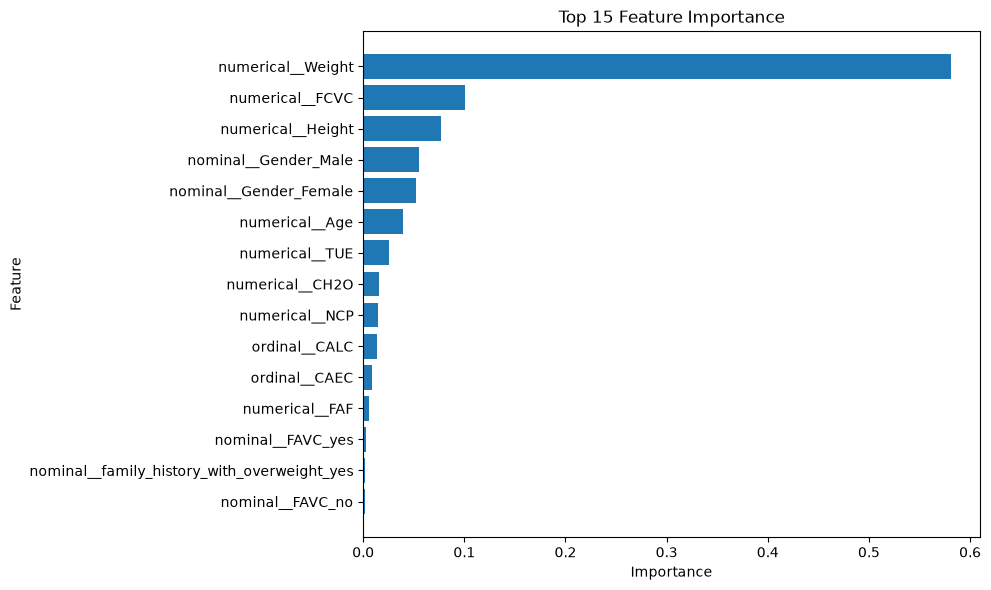

In [ ]:
# Top 15 important features
top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance")

plt.tight_layout()
plt.show()

In [ ]:
# Transform test data using preprocessing pipeline
X_test_transformed = np.asarray(
    final_model.named_steps["preprocessor"].transform(
        X_test
    )
)

classifier = final_model.named_steps["classifier"]

# Background data for SHAP
X_shap_background = X_test_transformed[:30]

def shap_predict_proba(data):
    return classifier.predict_proba(
        np.asarray(data)
    )

# Create SHAP explainer
explainer = shap.Explainer(
    shap_predict_proba,
    X_shap_background,
    algorithm="permutation",
    feature_names=list(feature_names),
    seed=42
)

# Explain limited samples
X_shap_sample = X_test_transformed[:100]

shap_values = explainer(
    X_shap_sample,
    max_evals=(2 * len(feature_names) + 1)
)

print("SHAP explainer created successfully")
print("SHAP shape:", shap_values.values.shape)

SHAP explainer created successfully
SHAP shape: (100, 25, 7)


Explaining class:
Obesity_Type_III
Class index:
4


C:\Users\User\AppData\Local\Temp\ipykernel_10484\3288936110.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


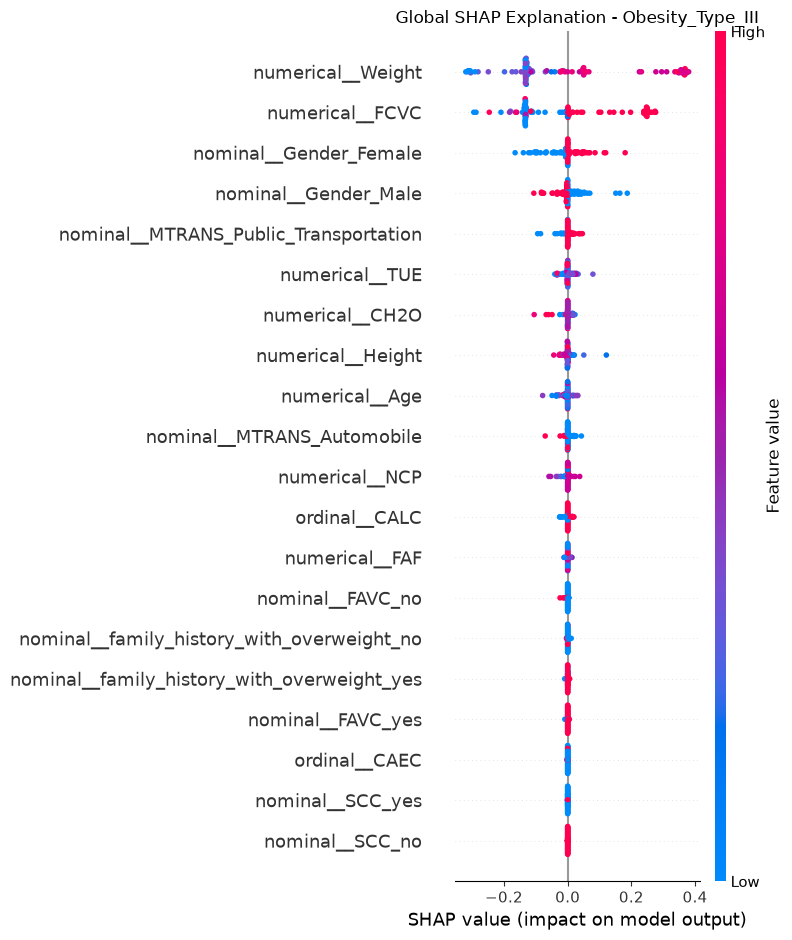

In [ ]:
# Select class for global explanation
# Obesity_Type_III class explanation
explain_class = "Obesity_Type_III"

class_index = metadata["dataset"]["classes"].index(
    explain_class
)

print("Explaining class:")
print(explain_class)

print("Class index:")
print(class_index)

# Generate global SHAP summary plot
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values.values[:, :, class_index],
    X_shap_sample,
    feature_names=feature_names,
    show=False
)

plt.title(
    f"Global SHAP Explanation - {explain_class}"
)

plt.tight_layout()

plt.show()

In [ ]:
# Select one test sample to explain
sample_index = 0
sample = X_shap_sample[sample_index]

# Generate prediction
prediction = classifier.predict(
    sample.reshape(1, -1)
)[0]

# Generate prediction probabilities
probability = classifier.predict_proba(
    sample.reshape(1, -1)
)[0]

print("Sample index:", sample_index)
print("Predicted class:", prediction)

print("\nClass probabilities:")

for class_name, prob in zip(
    metadata["dataset"]["classes"],
    probability
):
    print(f"{class_name}: {prob:.4f}")

# Extract SHAP values for predicted class
sample_shap = shap_values.values[sample_index]

# Find index of predicted class
class_index = metadata["dataset"]["classes"].index(
    prediction
)

# Select SHAP values related to predicted class
predicted_class_shap = sample_shap[:, class_index]

# Create explanation dataframe
local_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "SHAP Value": predicted_class_shap
    }
)

# Calculate contribution magnitude
local_df["Absolute Impact"] = (
    local_df["SHAP Value"]
    .abs()
)

# Sort by highest impact
local_df = local_df.sort_values(
    by="Absolute Impact",
    ascending=False
).reset_index(drop=True)

print("\nTop contributing features:")

display(
    local_df.head(10)
)

Sample index: 0
Predicted class: Obesity_Type_III

Class probabilities:
Insufficient_Weight: 0.0000
Normal_Weight: 0.0000
Obesity_Type_I: 0.0007
Obesity_Type_II: 0.0000
Obesity_Type_III: 0.9992
Overweight_Level_I: 0.0000
Overweight_Level_II: 0.0000

Top contributing features:


,Feature,SHAP Value,Absolute Impact
0,numerical__Weight,0.276845,0.276845
1,numerical__FCVC,0.239124,0.239124
2,nominal__Gender_Male,0.052496,0.052496
3,nominal__MTRANS_Public_Transportation,0.046105,0.046105
4,numerical__TUE,0.032796,0.032796
5,numerical__NCP,0.018896,0.018896
6,ordinal__CALC,0.018272,0.018272
7,numerical__CH2O,0.016075,0.016075
8,nominal__MTRANS_Automobile,0.011515,0.011515
9,nominal__Gender_Female,0.008428,0.008428


In [ ]:
# Create reports directory if not available
REPORTS.mkdir(
    parents=True,
    exist_ok=True
)

# Save feature importance results
importance_path = REPORTS / "feature_importance.csv"

importance_df.to_csv(
    importance_path,
    index=False
)

# Save local SHAP explanation
shap_local_path = REPORTS / "local_shap_explanation.csv"

local_df.to_csv(
    shap_local_path,
    index=False
)

print("Saved:")
print(importance_path)
print(shap_local_path)

Saved:
C:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated\feature_importance.csv
C:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated\local_shap_explanation.csv


In [ ]:
feature_file = REPORTS / "feature_importance.csv"
shap_file = REPORTS / "local_shap_explanation.csv"

print("Feature importance file exists:",
      feature_file.exists())

print("Local SHAP explanation file exists:",
      shap_file.exists())

if feature_file.exists() and shap_file.exists():
    print("\nExplainability workflow completed successfully")
else:
    print("\nSome explainability outputs are missing")

Feature importance file exists: True
Local SHAP explanation file exists: True

Explainability workflow completed successfully
